<a href="https://colab.research.google.com/github/Gabzedu/house-decision-financial-analysis/blob/main/notebook/house_decision_financial_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Decision Financial Analysis

## 1. Problem Statement
This project is based on income and expense records from 2022 to 2026 (June).
The goal is to explore two possible variables tied to a house purchase decision — Option A and Option B — relative to the current financial situation.
Through this analysis, I want to understand how my lifestyle and savings would look under each option, and use that comparison to support the decision.


**Key questions:**
- How does each housing option (Current situation, Option A, Option B) affect monthly savings, in absolute terms and as a percentage of income (savings rate)?
- What lifestyle spending remains realistically possible under each scenario?

> **Note:**
Although records exist from 2022, only 2023–2026 (June) are used in this analysis. Pre-2023 data is less representative of the current financial reality (the author relocated to Ireland in 2023), so restricting the period gives more realistic baseline figures.


## 2. Data

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

Saving house-decision-financial-analysis.xlsx to house-decision-financial-analysis (4).xlsx


In [11]:
expenses = pd.read_excel('house-decision-financial-analysis.xlsx', sheet_name='Expenses')
expenses.head()

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Slicer List extension is not supported and will be removed
  warn(msg)


,Year,Month,Category,Subcategory,Amount,Description,Split_Type,Extra Category,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,2022,May,Essentials,Bills,16.8,Phone,Individual,NaN,NaN,Year,Month,Category,Subcategory,Soma de Amount
1,2022,May,Lifestyle,Projects & Studies,200.0,College,Individual,NaN,NaN,2022,May,NaN,NaN,1480.82
2,2022,May,Lifestyle,Subscriptions & Services,30.9,Gym,Individual,NaN,NaN,NaN,June,NaN,NaN,840.83
3,2022,May,Essentials,Rent,175.0,Portugal Rent,50 - 50,NaN,NaN,NaN,July,NaN,NaN,817.74
4,2022,May,Essentials,Transportation,75.0,Diesel,Individual,NaN,NaN,NaN,August,NaN,NaN,881.6


In [12]:
expenses.columns = expenses.columns.str.strip()

expenses = expenses[['Year', 'Month', 'Category', 'Subcategory', 'Amount', 'Description', 'Split_Type', 'Extra Category']].copy()
expenses.head()

,Year,Month,Category,Subcategory,Amount,Description,Split_Type,Extra Category
0,2022,May,Essentials,Bills,16.8,Phone,Individual,NaN
1,2022,May,Lifestyle,Projects & Studies,200.0,College,Individual,NaN
2,2022,May,Lifestyle,Subscriptions & Services,30.9,Gym,Individual,NaN
3,2022,May,Essentials,Rent,175.0,Portugal Rent,50 - 50,NaN
4,2022,May,Essentials,Transportation,75.0,Diesel,Individual,NaN


In [13]:
income = pd.read_excel('house-decision-financial-analysis.xlsx', sheet_name='Income')
income.head()

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Slicer List extension is not supported and will be removed
  warn(msg)


,Year,Month,Category,Subcategorie,Amount,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,2022,May,Government Support,Unemployment Benefits,509.38,NaN,Year,Month,Category,Subcategorie,Soma de Amount
1,2022,May,Government Support,Student Support,87.20,NaN,2022,May,NaN,NaN,1480.84
2,2022,May,Other Income,Savings Withdrawal,649.63,NaN,NaN,June,NaN,NaN,848.71
3,2022,May,Government Support,Tax Refund,234.63,NaN,NaN,July,NaN,NaN,824.88
4,2022,June,Government Support,Unemployment Benefits,509.38,NaN,NaN,August,NaN,NaN,896.03


In [14]:
income.columns = income.columns.str.strip()

income = income[['Year', 'Month', 'Category', 'Subcategorie', 'Amount']]
income.head()

,Year,Month,Category,Subcategorie,Amount
0,2022,May,Government Support,Unemployment Benefits,509.38
1,2022,May,Government Support,Student Support,87.20
2,2022,May,Other Income,Savings Withdrawal,649.63
3,2022,May,Government Support,Tax Refund,234.63
4,2022,June,Government Support,Unemployment Benefits,509.38


## 3. Data Cleaning & Transformation

In [15]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

expenses['Month_num'] = expenses['Month'].apply(lambda m: month_order.index(m) + 1)

expenses_filtered = expenses[
    (expenses['Year'] >= 2023) &
    ((expenses['Year'] < 2026) | ((expenses['Year'] == 2026) & (expenses['Month_num'] <= 6)))
].copy()

expenses_filtered['Year'].value_counts().sort_index()


,count
Year,
2023,143
2024,139
2025,137
2026,83


In [16]:
set(income['Month'].unique()) - set(month_order)

{'February ', 'January ', 'November '}

In [17]:
income['Month'] = income['Month'].str.strip()
income['Month_num'] = income['Month'].apply(lambda m: month_order.index(m) + 1)

income_filtered = income[
    (income['Year'] >= 2023) &
    ((income['Year'] < 2026) | ((income['Year'] == 2026) & (income['Month_num'] <= 6)))
].copy()

income_filtered['Year'].value_counts().sort_index()

,count
Year,
2023,33
2024,65
2025,70
2026,29


In [18]:
print("Duplicates:", expenses_filtered.duplicated().sum())
print()

Duplicates: 4



In [19]:
expenses_filtered[expenses_filtered.duplicated(keep=False)].sort_values(['Year', 'Month', 'Amount'])

,Year,Month,Category,Subcategory,Amount,Description,Split_Type,Extra Category,Month_num
325,2024,July,Essentials,Bills,50.0,Electricity,50 - 50,House Related Bills,7
329,2024,July,Essentials,Bills,50.0,Electricity,50 - 50,House Related Bills,7
307,2024,May,Essentials,Bills,25.0,Electricity,50 - 50,House Related Bills,5
310,2024,May,Essentials,Bills,25.0,Electricity,50 - 50,House Related Bills,5
429,2025,April,Essentials,Bills,50.0,Electricity,50 - 50,House Related Bills,4
431,2025,April,Essentials,Bills,50.0,Electricity,50 - 50,House Related Bills,4
505,2025,November,Essentials,Bills,50.0,Electricity,50 - 50,House Related Bills,11
507,2025,November,Essentials,Bills,50.0,Electricity,50 - 50,House Related Bills,11


In [20]:
print("Duplicates (income):", income_filtered.duplicated().sum())

Duplicates (income): 6


In [21]:
income_filtered[income_filtered.duplicated(keep=False)].sort_values(['Year', 'Month', 'Amount'])

,Year,Month,Category,Subcategorie,Amount,Month_num
50,2023,November,Salary,Tesco,440.5,11
51,2023,November,Salary,Tesco,440.5,11
46,2023,October,Salary,Tesco,440.5,10
47,2023,October,Salary,Tesco,440.5,10
48,2023,October,Salary,Tesco,440.5,10
49,2023,October,Salary,Tesco,440.5,10
104,2024,October,Salary,babysitting,78.0,10
107,2024,October,Salary,babysitting,78.0,10
192,2025,December,Salary,Tips,60.0,12
193,2025,December,Salary,Tips,60.0,12


In [22]:
print("Missing values (expenses):")
print(expenses_filtered.isna().sum())
print()
print("Missing values (income):")
print(income_filtered.isna().sum())

Missing values (expenses):
Year               0
Month              0
Category           0
Subcategory        0
Amount             0
Description       25
Split_Type         0
Extra Category     0
Month_num          0
dtype: int64

Missing values (income):
Year            0
Month           0
Category        0
Subcategorie    0
Amount          0
Month_num       0
dtype: int64


In [23]:
expenses_filtered[expenses_filtered['Description'].isna()]

,Year,Month,Category,Subcategory,Amount,Description,Split_Type,Extra Category,Month_num
120,2023,January,Unknown,Unknown,3.43,NaN,Individual,Personal spendings,1
142,2023,March,Unknown,Unknown,4.48,NaN,Individual,Personal spendings,3
152,2023,April,Unknown,Unknown,22.22,NaN,Individual,Personal spendings,4
163,2023,May,Unknown,Unknown,7.44,NaN,Individual,Personal spendings,5
175,2023,June,Unknown,Unknown,14.13,NaN,Individual,Personal spendings,6
186,2023,July,Unknown,Unknown,5.06,NaN,Individual,Personal spendings,7
198,2023,August,Unknown,Unknown,10.77,NaN,Individual,Personal spendings,8
209,2023,September,Unknown,Unknown,21.29,NaN,Individual,Personal spendings,9
220,2023,October,Unknown,Unknown,18.04,NaN,Individual,Personal spendings,10
230,2023,November,Unknown,Unknown,8.28,NaN,Individual,Personal spendings,11


In [24]:
expenses_filtered.loc[
    (expenses_filtered['Description'].isna()) & (expenses_filtered['Subcategory'] != 'Unknown'),
    'Description'
] = expenses_filtered['Subcategory']

expenses_filtered.loc[
    expenses_filtered['Description'].isna(),
    'Description'
] = 'Unknown'

print("Remaining missing Description:", expenses_filtered['Description'].isna().sum())

Remaining missing Description: 0


In [25]:
print("Unique values - Category:")
print(expenses_filtered['Category'].unique())
print()
print("Unique values - Subcategory:")
print(expenses_filtered['Subcategory'].unique())
print()
print("Unique values - Split_Type:")
print(expenses_filtered['Split_Type'].unique())
print()
print("Unique values - Extra Category:")
print(expenses_filtered['Extra Category'].unique())

Unique values - Category:
['Essentials' 'Lifestyle' 'Unknown']

Unique values - Subcategory:
['Rent' 'Bills' 'Transportation' 'Groceries' 'Dog supplies'
 'Projects & Studies' 'Eating Out' 'Shopping' 'Unknown' 'Health' 'Travel'
 'Veterinary ' 'Health ' 'Subscriptions & Services']

Unique values - Split_Type:
['50 - 50' 'Individual']

Unique values - Extra Category:
['House Related Bills' 'Expeted Bills' 'Personal spendings '
 'Unexpected Bills']


In [26]:
# Clean whitespace in all text columns
text_cols = ['Category', 'Subcategory', 'Split_Type', 'Extra Category', 'Description']
for col in text_cols:
    expenses_filtered[col] = expenses_filtered[col].str.strip()

# Fix known typo
expenses_filtered['Extra Category'] = expenses_filtered['Extra Category'].replace('Expeted Bills', 'Expected Bills')

# Re-check
print("Category:", expenses_filtered['Category'].unique())
print()
print("Subcategory:", expenses_filtered['Subcategory'].unique())
print()
print("Extra Category:", expenses_filtered['Extra Category'].unique())

Category: ['Essentials' 'Lifestyle' 'Unknown']

Subcategory: ['Rent' 'Bills' 'Transportation' 'Groceries' 'Dog supplies'
 'Projects & Studies' 'Eating Out' 'Shopping' 'Unknown' 'Health' 'Travel'
 'Veterinary' 'Subscriptions & Services']

Extra Category: ['House Related Bills' 'Expected Bills' 'Personal spendings'
 'Unexpected Bills']


In [27]:
print("Category:", income_filtered['Category'].unique())
print()
print("Subcategorie:", income_filtered['Subcategorie'].unique())

Category: ['Salary' 'Other Income']

Subcategorie: ['BI' 'Family Support' 'Gifts' 'Savings Withdrawal' 'Tesco' 'Zanzibar'
 'babysitting' 'Tips' 'Tax refund']


In [28]:
print("Expenses - min/max Amount:", expenses_filtered['Amount'].min(), "/", expenses_filtered['Amount'].max())
print("Income - min/max Amount:", income_filtered['Amount'].min(), "/", income_filtered['Amount'].max())
print()
print("Expenses rows with Amount <= 0:", (expenses_filtered['Amount'] <= 0).sum())
print("Income rows with Amount <= 0:", (income_filtered['Amount'] <= 0).sum())

Expenses - min/max Amount: 1.99 / 1125.0
Income - min/max Amount: 19.0 / 1200.0

Expenses rows with Amount <= 0: 0
Income rows with Amount <= 0: 0


In [29]:
income_filtered['Category'] = income_filtered['Category'].str.strip()
income_filtered['Subcategorie'] = income_filtered['Subcategorie'].str.strip()

In [30]:
print("Expenses dtypes:")
print(expenses_filtered.dtypes)
print()
print("Income dtypes:")
print(income_filtered.dtypes)

Expenses dtypes:
Year                int64
Month              object
Category           object
Subcategory        object
Amount            float64
Description        object
Split_Type         object
Extra Category     object
Month_num           int64
dtype: object

Income dtypes:
Year              int64
Month            object
Category         object
Subcategorie     object
Amount          float64
Month_num         int64
dtype: object


## 4. Exploratory Data Analysis




In [31]:
income_filtered.groupby('Year')['Amount'].sum()

,Amount
Year,
2023,15449.53
2024,17709.07
2025,22960.15
2026,12948.63


In [32]:
expenses_filtered.groupby('Category')['Amount'].sum()

,Amount
Category,
Essentials,35262.15
Lifestyle,23027.16
Unknown,248.69


In [35]:
essentials = expenses_filtered[expenses_filtered['Category'] == 'Essentials']
essentials.head()

,Year,Month,Category,Subcategory,Amount,Description,Split_Type,Extra Category,Month_num
110,2023,January,Essentials,Rent,175.00,Portugal Rent,50 - 50,House Related Bills,1
111,2023,January,Essentials,Bills,64.80,Electricity,50 - 50,House Related Bills,1
112,2023,January,Essentials,Transportation,64.38,Diesel,Individual,Expected Bills,1
113,2023,January,Essentials,Groceries,139.20,Groceries,50 - 50,Expected Bills,1
114,2023,January,Essentials,Dog supplies,14.90,Dog supplies,50 - 50,Expected Bills,1


In [36]:
# Total spent (€) per subcategory within Essentials
essentials.groupby('Subcategory')['Amount'].sum().sort_values(ascending=False)

,Amount
Subcategory,
Rent,18575.00
Groceries,7824.22
Bills,3776.42
Transportation,3537.34
Dog supplies,1029.95
Veterinary,261.79
Health,257.43


In [37]:
# Total spent (€) per Subcategory, broken down by Extra Category
essentials.groupby(['Extra Category', 'Subcategory'])['Amount'].sum().sort_values(ascending=False)

Extra Category       Subcategory   
House Related Bills  Rent              18575.00
Expected Bills       Groceries          7495.51
House Related Bills  Bills              2195.00
Unexpected Bills     Transportation     1795.20
Expected Bills       Transportation     1742.14
                     Bills              1536.22
                     Dog supplies       1029.95
Unexpected Bills     Veterinary          261.79
                     Health              257.43
                     Groceries           217.71
Personal spendings   Groceries           111.00
Unexpected Bills     Bills                45.20
Name: Amount, dtype: float64

In [38]:
# Monthly average (€) per Subcategory within Essentials
n_months = expenses_filtered[['Year', 'Month_num']].drop_duplicates().shape[0]
print("Number of months in period:", n_months)

monthly_avg_subcat = essentials.groupby('Subcategory')['Amount'].sum() / n_months
monthly_avg_subcat.sort_values(ascending=False)

Number of months in period: 42


,Amount
Subcategory,
Rent,442.261905
Groceries,186.290952
Bills,89.914762
Transportation,84.222381
Dog supplies,24.522619
Veterinary,6.233095
Health,6.129286


In [39]:
lifestyle = expenses_filtered[expenses_filtered['Category'] == 'Lifestyle']

# Monthly average (€) per Subcategory within Lifestyle
n_months = expenses_filtered[['Year', 'Month_num']].drop_duplicates().shape[0]

monthly_avg_lifestyle = lifestyle.groupby('Subcategory')['Amount'].sum() / n_months
monthly_avg_lifestyle.sort_values(ascending=False)

,Amount
Subcategory,
Shopping,195.595476
Travel,143.433333
Projects & Studies,102.592619
Eating Out,87.063095
Subscriptions & Services,19.438333
Unknown,0.142857


In [40]:
# Savings by year (author only)
income_by_year = income_filtered.groupby('Year')['Amount'].sum()
essentials_by_year = essentials.groupby('Year')['Amount'].sum()
lifestyle_by_year = lifestyle.groupby('Year')['Amount'].sum()

savings_by_year = income_by_year - essentials_by_year - lifestyle_by_year
savings_by_year

,Amount
Year,
2023,1461.95
2024,2349.99
2025,4738.89
2026,2227.24


In [41]:
# Monthly average savings by year (fair comparison)
months_per_year_all = expenses_filtered.groupby('Year')['Month_num'].nunique()

savings_monthly_by_year = savings_by_year / months_per_year_all
savings_monthly_by_year

,0
Year,
2023,121.829167
2024,195.832500
2025,394.907500
2026,371.206667


## 5. Visualisation & Insights




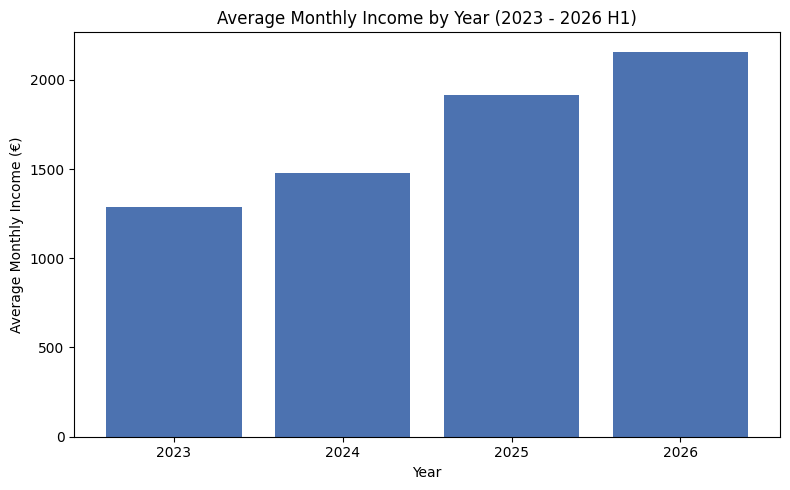

In [42]:
# Monthly average income per year (fair comparison across years with different data coverage)
months_per_year = income_filtered.groupby('Year')['Month_num'].nunique()
income_by_year = income_filtered.groupby('Year')['Amount'].sum()
avg_monthly_income = income_by_year / months_per_year

plt.figure(figsize=(8, 5))
plt.bar(avg_monthly_income.index.astype(str), avg_monthly_income.values, color='#4C72B0')
plt.title('Average Monthly Income by Year (2023 - 2026 H1)')
plt.xlabel('Year')
plt.ylabel('Average Monthly Income (€)')
plt.tight_layout()
plt.show()

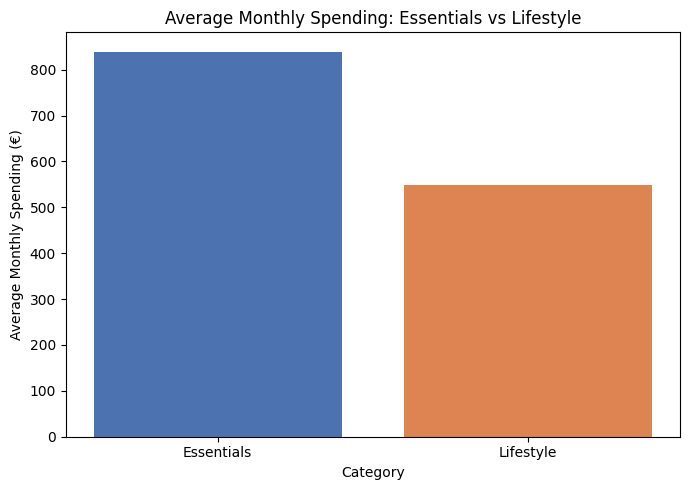

In [43]:
# Monthly average (€) - Essentials vs Lifestyle
n_months = expenses_filtered[['Year', 'Month_num']].drop_duplicates().shape[0]

category_totals = expenses_filtered[expenses_filtered['Category'].isin(['Essentials', 'Lifestyle'])].groupby('Category')['Amount'].sum()
category_monthly_avg = category_totals / n_months

plt.figure(figsize=(7, 5))
plt.bar(category_monthly_avg.index, category_monthly_avg.values, color=['#4C72B0', '#DD8452'])
plt.title('Average Monthly Spending: Essentials vs Lifestyle')
plt.xlabel('Category')
plt.ylabel('Average Monthly Spending (€)')
plt.tight_layout()
plt.show()

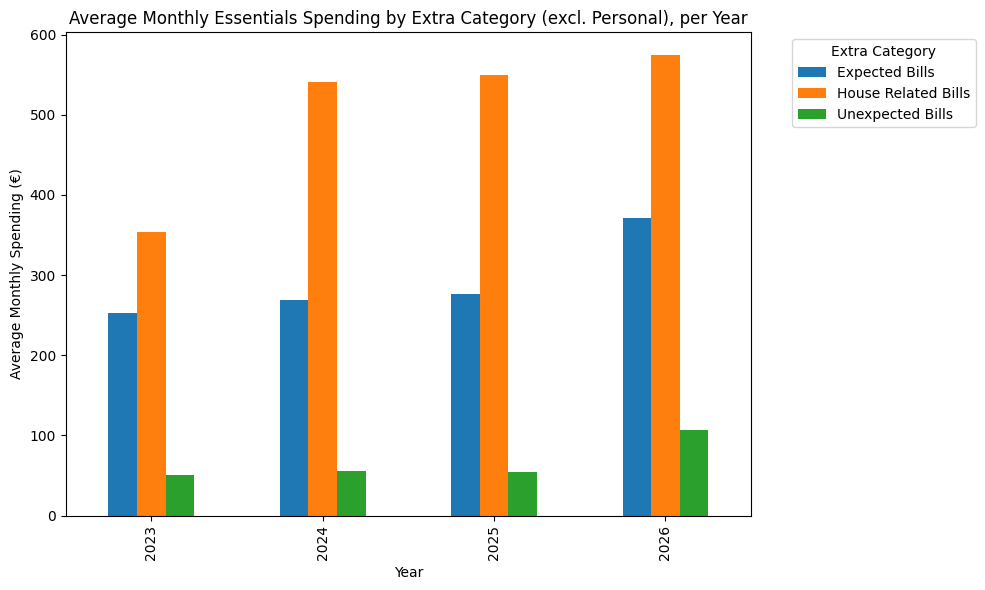

In [44]:
# Monthly average (€) - Essentials by Extra Category (excluding Personal spendings), per year - want to explore the bills section
n_months_per_year = expenses_filtered.groupby('Year')['Month_num'].nunique()

essentials = expenses_filtered[
    (expenses_filtered['Category'] == 'Essentials') &
    (expenses_filtered['Extra Category'] != 'Personal spendings')
]

essentials_by_year_extra = essentials.groupby(['Year', 'Extra Category'])['Amount'].sum().unstack()
essentials_monthly_avg = essentials_by_year_extra.div(n_months_per_year, axis=0)

essentials_monthly_avg.plot(kind='bar', figsize=(10, 6))
plt.title('Average Monthly Essentials Spending by Extra Category (excl. Personal), per Year')
plt.xlabel('Year')
plt.ylabel('Average Monthly Spending (€)')
plt.legend(title='Extra Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [45]:
# Summary of real monthly averages to feed into house_plans
n_months = expenses_filtered[['Year', 'Month_num']].drop_duplicates().shape[0]

essentials_summary = essentials.groupby('Extra Category')['Amount'].sum() / n_months
lifestyle_summary = lifestyle['Amount'].sum() / n_months
income_summary = income_filtered['Amount'].sum() / n_months

print("=== Monthly averages (author only, 2023-2026 H1) ===")
print(essentials_summary)
print()
print("Lifestyle (monthly avg):", round(lifestyle_summary, 2))
print("Income (monthly avg):", round(income_summary, 2))

=== Monthly averages (author only, 2023-2026 H1) ===
Extra Category
Expected Bills         281.043333
House Related Bills    494.523810
Unexpected Bills        61.365000
Name: Amount, dtype: float64

Lifestyle (monthly avg): 548.27
Income (monthly avg): 1644.46


In [46]:
income_2026_avg = income_filtered[income_filtered['Year'] == 2026]['Amount'].sum() / income_filtered[income_filtered['Year'] == 2026]['Month_num'].nunique()
print("Income 2026 (monthly avg):", round(income_2026_avg, 2))

Income 2026 (monthly avg): 2158.1


In [47]:
savings_rate = savings_monthly / income_monthly_current * 100

plt.figure(figsize=(7, 5))
plt.bar(breakdown.index, breakdown.values, color=['#C44E52', '#DD8452', '#55A868'])
plt.title(f'Monthly Breakdown: Essentials vs Lifestyle vs Savings (Current)\nSavings Rate: {savings_rate:.1f}%')
plt.ylabel('Amount (€)')
plt.tight_layout()
plt.show()

print(breakdown.round(2))
print(f"\nSavings rate: {savings_rate:.1f}%")

NameError: name 'savings_monthly' is not defined

In [48]:
from google.colab import files
files.download('house-decision-financial-analysis.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 6. Key Insights

- Income increased consistently every year from 2023 to 2026, with a notable jump in 2026 following a salary raise.
- Monthly average savings grew steadily from 2023 (€121.83) to 2025 (€404.16), but slightly declined in 2026 (€371.21) despite the higher income — driven by a rise in Unexpected Bills that year.
- Essential expenses consistently exceed lifestyle spending on a monthly basis, reflecting a spending pattern weighted toward fixed obligations rather than discretionary spending.
- Current monthly savings rate stands at approximately 35.8%, based on 2026 income and 2023–2026 average expenses.

## 7. Conclusions & Next Steps

**Conclusions:**
This notebook does not answer which housing option is best — that comparison happens in Tableau, where the author's real monthly figures (calculated here) are combined with the partner's estimated figures and the specific cost of each housing option. What this analysis provides is a validated, data-grounded baseline for the author's own finances: real monthly averages for essential expenses, lifestyle spending, and current income, replacing rough estimates with figures calculated directly from transaction-level data.


**Next Steps:**
- Build the scenario comparison in Tableau, combining these validated figures with partner estimates and the housing costs already defined for the Current, Option A, and Option B scenarios.
- Calculate savings and savings rate for each scenario, using the author's real Lifestyle average as a fixed reference point.
- Note as a limitation: partner data is estimated (residual method), not transaction-level; the 2026 rise in Unexpected Bills may not be representative of a long-term pattern.